<a href="https://colab.research.google.com/github/irungus/tree-species-ml-pipeline/blob/main/notebooks/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Am going to import the data

In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

Import data from my github

In [3]:
url = "https://raw.githubusercontent.com/irungus/tree-species-ml-pipeline/main/data/raw/final_features.csv"
df = pd.read_csv(url)

print(df.head())
print(f"Total points: {len(df)}")

    uid     species  latitude  longitude       EVI      NDVI      SAVI  \
0  6042      Acacia -4.537429  39.139728  0.476082  0.251262  0.376848   
1  5988  Eucalyptus -4.522492  39.183680  0.711032  0.334040  0.501006   
2  5985  Eucalyptus -4.522487  39.183677  0.711032  0.334040  0.501006   
3  5982  Eucalyptus -4.522480  39.183657  0.711032  0.334040  0.501006   
4  5932  Eucalyptus -4.472281  39.189929  1.502694  0.298845  0.448226   

          VH         VV  VV_VH_ratio  ...  temperature_2m  \
0 -18.147271 -12.876735     0.709569  ...      299.024417   
1 -16.980324 -12.548029     0.738975  ...      299.116702   
2 -16.980324 -12.548029     0.738975  ...      299.116702   
3 -16.980324 -12.548029     0.738975  ...      299.116702   
4 -14.763931  -6.612564     0.447886  ...      299.116702   

   temperature_of_snow_layer  total_evaporation  total_precipitation  \
0                 273.160174          -0.001593             0.001282   
1                 273.160174          -0.001

In [4]:
df.columns

Index(['uid', 'species', 'latitude', 'longitude', 'EVI', 'NDVI', 'SAVI', 'VH',
       'VV', 'VV_VH_ratio', 'elevation', 'slope', 'dewpoint_temperature_2m',
       'evaporation_from_bare_soil',
       'evaporation_from_open_water_surfaces_excluding_oceans',
       'evaporation_from_the_top_of_canopy',
       'evaporation_from_vegetation_transpiration', 'forecast_albedo',
       'lake_bottom_temperature', 'lake_ice_depth', 'lake_ice_temperature',
       'lake_mix_layer_depth', 'lake_mix_layer_temperature',
       'lake_shape_factor', 'lake_total_layer_temperature',
       'leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation',
       'potential_evaporation', 'runoff', 'skin_reservoir_content',
       'skin_temperature', 'snow_albedo', 'snow_cover', 'snow_density',
       'snow_depth', 'snow_depth_water_equivalent', 'snow_evaporation',
       'snowfall', 'snowmelt', 'soil_temperature_level_1',
       'soil_temperature_level_2', 'soil_temperature_level_3',
       'soil_tempera

Selecting relevant features

In [5]:
selected_features = [
    'NDVI', 'EVI', 'SAVI', 'VV', 'VH',
    'VV_VH_ratio', 'elevation', 'slope', 'temperature_2m', 'total_precipitation'
]

In [6]:
columns_to_keep = ['species', 'latitude', 'longitude'] + selected_features
df = df[columns_to_keep]

In [7]:
df.head()

,species,latitude,longitude,NDVI,EVI,SAVI,VV,VH,VV_VH_ratio,elevation,slope,temperature_2m,total_precipitation
0,Acacia,-4.537429,39.139728,0.251262,0.476082,0.376848,-12.876735,-18.147271,0.709569,73,4.732799,299.024417,0.001282
1,Eucalyptus,-4.522492,39.183680,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486
2,Eucalyptus,-4.522487,39.183677,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486
3,Eucalyptus,-4.522480,39.183657,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486
4,Eucalyptus,-4.472281,39.189929,0.298845,1.502694,0.448226,-6.612564,-14.763931,0.447886,97,3.716075,299.116702,0.001486


SAR Feature Engeneering
  - enhances vegetation structure detection
  - common in remote sensing ML

In [8]:
df['VV_minus_VH'] = df['VV'] - df['VH']

Vegetation Feature Engineering
 - helps capture nonlinear relationships
 - vegetation behaves differently across altitude

In [9]:
df['NVDI_squared'] = df['NDVI'] ** 2
df['NVDI_elevation']= df['NDVI'] * df['elevation']


In [10]:
df.head()

,species,latitude,longitude,NDVI,EVI,SAVI,VV,VH,VV_VH_ratio,elevation,slope,temperature_2m,total_precipitation,VV_minus_VH,NVDI_squared,NVDI_elevation
0,Acacia,-4.537429,39.139728,0.251262,0.476082,0.376848,-12.876735,-18.147271,0.709569,73,4.732799,299.024417,0.001282,5.270536,0.063133,18.342150
1,Eucalyptus,-4.522492,39.183680,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486,4.432295,0.111582,10.021189
2,Eucalyptus,-4.522487,39.183677,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486,4.432295,0.111582,10.021189
3,Eucalyptus,-4.522480,39.183657,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486,4.432295,0.111582,10.021189
4,Eucalyptus,-4.472281,39.189929,0.298845,1.502694,0.448226,-6.612564,-14.763931,0.447886,97,3.716075,299.116702,0.001486,8.151367,0.089308,28.987991


Handling missing values

In [11]:
df.isnull().sum()

,0
species,0
latitude,0
longitude,0
NDVI,0
EVI,0
SAVI,0
VV,0
VH,0
VV_VH_ratio,0
elevation,0


simple imputation

In [12]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(df.drop('species', axis=1))

Feature scaling

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
df.head()

,species,latitude,longitude,NDVI,EVI,SAVI,VV,VH,VV_VH_ratio,elevation,slope,temperature_2m,total_precipitation,VV_minus_VH,NVDI_squared,NVDI_elevation
0,Acacia,-4.537429,39.139728,0.251262,0.476082,0.376848,-12.876735,-18.147271,0.709569,73,4.732799,299.024417,0.001282,5.270536,0.063133,18.342150
1,Eucalyptus,-4.522492,39.183680,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486,4.432295,0.111582,10.021189
2,Eucalyptus,-4.522487,39.183677,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486,4.432295,0.111582,10.021189
3,Eucalyptus,-4.522480,39.183657,0.334040,0.711032,0.501006,-12.548029,-16.980324,0.738975,30,1.313490,299.116702,0.001486,4.432295,0.111582,10.021189
4,Eucalyptus,-4.472281,39.189929,0.298845,1.502694,0.448226,-6.612564,-14.763931,0.447886,97,3.716075,299.116702,0.001486,8.151367,0.089308,28.987991


feature selection

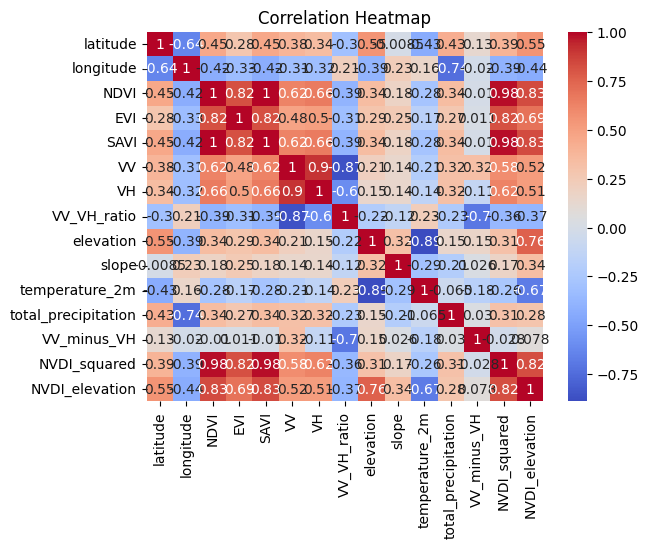

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Feature Importance

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf = RandomForestClassifier()
rf.fit(X_scaled, df['species'])

importances = rf.feature_importances_

feature_names = df.drop(['species', 'latitude', 'longitude'], axis=1).columns

for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance}")

NDVI: 0.13352812363639666
EVI: 0.12058400224970382
SAVI: 0.05777070926964509
VV: 0.04098656816263448
VH: 0.05395191428979275
VV_VH_ratio: 0.047016632447230255
elevation: 0.03715296926379839
slope: 0.05901357085081145
temperature_2m: 0.09178902226187406
total_precipitation: 0.0549730102236382
VV_minus_VH: 0.049724479280367086
NVDI_squared: 0.048425206983218304
NVDI_elevation: 0.052487334634824946


In [28]:
columns_to_keep = ['NDVI', 'EVI', 'SAVI', 'VV', 'VH','VV_minus_VH', 'NVDI_squared', 'NVDI_elevation', 'total_precipitation','temperature_2m','slope','VV_VH_ratio','species']
df = df[columns_to_keep]
df.to_csv("features.csv", index=False)

In [27]:
df.head()

,NDVI,EVI,SAVI,VV,VH,VV_minus_VH,NVDI_squared,NVDI_elevation,total_precipitation,temperature_2m,slope,VV_VH_ratio,species
0,0.251262,0.476082,0.376848,-12.876735,-18.147271,5.270536,0.063133,18.342150,0.001282,299.024417,4.732799,0.709569,Acacia
1,0.334040,0.711032,0.501006,-12.548029,-16.980324,4.432295,0.111582,10.021189,0.001486,299.116702,1.313490,0.738975,Eucalyptus
2,0.334040,0.711032,0.501006,-12.548029,-16.980324,4.432295,0.111582,10.021189,0.001486,299.116702,1.313490,0.738975,Eucalyptus
3,0.334040,0.711032,0.501006,-12.548029,-16.980324,4.432295,0.111582,10.021189,0.001486,299.116702,1.313490,0.738975,Eucalyptus
4,0.298845,1.502694,0.448226,-6.612564,-14.763931,8.151367,0.089308,28.987991,0.001486,299.116702,3.716075,0.447886,Eucalyptus
